# Actividad 12 — GC1: Prophet (Grupo de Control Base)

**Fase 3 — Entrenamiento de Modelos**  
**Proyecto:** Predicción de Demanda Agroindustrial — Limón Peruano  

## Objetivo
Entrenar el modelo **Prophet** (Meta/Facebook) sobre la serie univariada de producción mensual nacional
como segundo modelo del Grupo de Control (GC1), complementando el SARIMA de la Actividad 11.

## Protocolo de validación
- Agregación: **media provincial** (`.mean()`) — mismo criterio corregido del SARIMA
- Split **cronológico estricto 80/20** — sin aleatorización
- Prophet se ajusta **únicamente** sobre el conjunto de entrenamiento
- Las predicciones se generan para exactamente los `n_test` meses del período de prueba
- Datos en **escala z-score** (normalizados en Fase 2)

## Outputs
```
resultados/gc1/
  ├── gc1_prophet_model.pkl
  ├── gc1_prophet_metricas.json
  ├── gc1_prophet_predicciones.csv
  ├── gc1_prophet_componentes.png
  └── gc1_prophet_prediccion_vs_real.png
```

## 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import json
import joblib
from pathlib import Path

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.facecolor'] = 'white'

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
PROYECTO_ROOT  = Path(r'C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-')
DATASET_PATH   = PROYECTO_ROOT / 'data' / 'processed' / 'master_dataset_fase2_multivariado.csv'
RESULTADOS_DIR = PROYECTO_ROOT / 'resultados' / 'gc1'
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_RATIO  = 0.80
RANDOM_STATE = 42

print(f"Dataset   : {DATASET_PATH}")
print(f"Resultados: {RESULTADOS_DIR}")

Dataset   : C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-\data\processed\master_dataset_fase2_multivariado.csv
Resultados: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-\resultados\gc1


## 2. Carga del dataset

In [3]:
df = pd.read_csv(DATASET_PATH, parse_dates=['fecha_evento'])

print(f"Filas × columnas : {df.shape[0]:,} × {df.shape[1]}")
print(f"Rango temporal   : {df['fecha_evento'].min().date()} → {df['fecha_evento'].max().date()}")
print(f"Provincias       : {df['provincia'].nunique()}")
df.head(3)

Filas × columnas : 5,880 × 24
Rango temporal   : 2021-01-01 → 2025-08-01
Provincias       : 105


,fecha_evento,departamento,provincia,produccion_t,precio_chacra_kg,num_emergencias,total_afectados,hectareas_cultivo_perdidas,ALLSKY_SFC_SW_DWN,PRECTOTCORR,...,T2M_MIN,WS2M,lat,lon,month_sin,month_cos,mes_num,trimestre_num,trimestre_sin,trimestre_cos
0,2021-01-01,AMAZONAS,BAGUA,-0.197656,0.156650,0.360646,0.213194,-0.013941,-0.945428,-0.202610,...,0.469032,0.204645,-5.638889,-78.531111,0.500000,8.660254e-01,1,1,1.0,6.123234e-17
1,2021-02-01,AMAZONAS,BAGUA,-0.187033,-0.393473,0.360646,0.036943,-0.013941,-0.952026,-0.266286,...,0.650497,0.074091,-5.638889,-78.531111,0.866025,5.000000e-01,2,1,1.0,6.123234e-17
2,2021-03-01,AMAZONAS,BAGUA,-0.187614,-0.324707,3.717952,-0.083822,-0.013941,-1.153257,0.497834,...,0.489771,-0.108683,-5.638889,-78.531111,1.000000,6.123234e-17,3,1,1.0,6.123234e-17


## 3. Agregación a serie mensual nacional (media provincial)

Se usa `.mean()` — mismo criterio corregido del SARIMA — para evitar la escala errática
que produce sumar z-scores de 105 provincias.

In [4]:
serie_nacional = (
    df.groupby('fecha_evento')['produccion_t']
    .mean()
    .sort_index()
    .rename('produccion_t_media_provincial')
)
serie_nacional.index = pd.DatetimeIndex(serie_nacional.index, freq='MS')

print(f"Observaciones mensuales : {len(serie_nacional)}")
print(f"Período                 : {serie_nacional.index.min().date()} → {serie_nacional.index.max().date()}")
print(f"\nEstadísticas descriptivas (z-score):")
print(serie_nacional.describe().round(4))

Observaciones mensuales : 56
Período                 : 2021-01-01 → 2025-08-01

Estadísticas descriptivas (z-score):
count    56.0000
mean      0.0000
std       0.0705
min      -0.1338
25%      -0.0510
50%      -0.0072
75%       0.0424
max       0.1438
Name: produccion_t_media_provincial, dtype: float64


## 4. Split cronológico 80/20

Corte estrictamente temporal. Prophet recibe un DataFrame con columnas `ds` (fecha) e `y` (valor).

In [5]:
n_total = len(serie_nacional)
n_train = int(n_total * SPLIT_RATIO)
n_test  = n_total - n_train

y_train_raw = serie_nacional.iloc[:n_train]
y_test_raw  = serie_nacional.iloc[n_train:]
split_date  = serie_nacional.index[n_train]

# Formato requerido por Prophet
train_df = pd.DataFrame({'ds': y_train_raw.index, 'y': y_train_raw.values})
test_df  = pd.DataFrame({'ds': y_test_raw.index,  'y': y_test_raw.values})

print("=" * 55)
print(f"  Total observaciones : {n_total}")
print(f"  Entrenamiento (80%) : {n_train} meses")
print(f"    {y_train_raw.index.min().date()} → {y_train_raw.index.max().date()}")
print(f"  Prueba (20%)        : {n_test} meses")
print(f"    {y_test_raw.index.min().date()} → {y_test_raw.index.max().date()}")
print(f"  Corte cronológico   : {split_date.date()}")
print("=" * 55)
print("\nSplit cronológico estricto — sin aleatorización ni data leakage.")

  Total observaciones : 56
  Entrenamiento (80%) : 44 meses
    2021-01-01 → 2024-08-01
  Prueba (20%)        : 12 meses
    2024-09-01 → 2025-08-01
  Corte cronológico   : 2024-09-01

Split cronológico estricto — sin aleatorización ni data leakage.


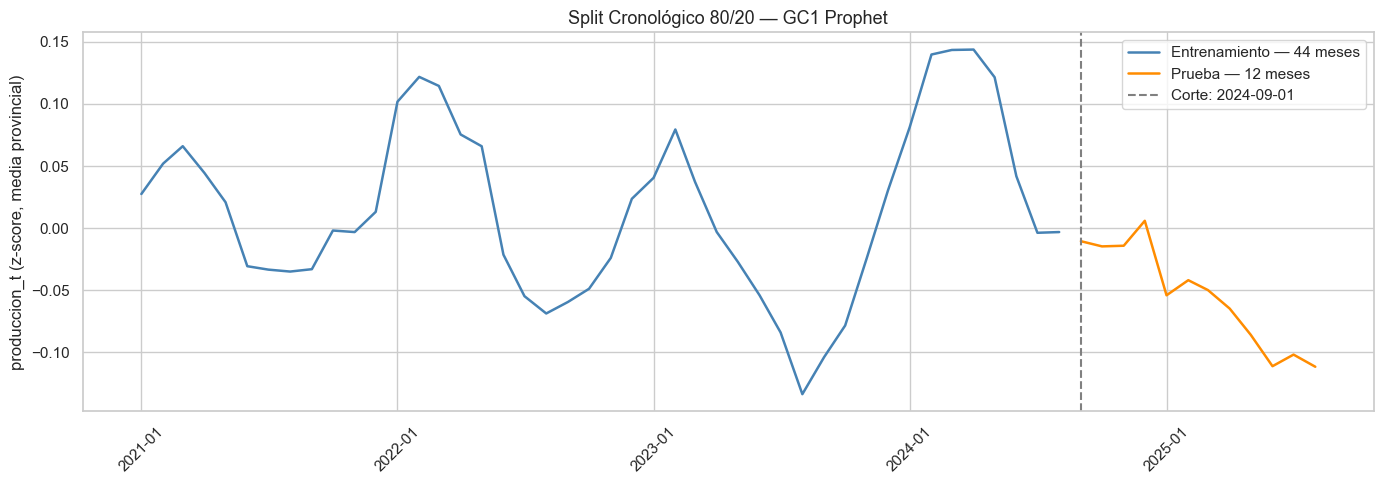

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_train_raw.index, y_train_raw.values,
        label=f'Entrenamiento — {n_train} meses', color='steelblue', linewidth=1.8)
ax.plot(y_test_raw.index,  y_test_raw.values,
        label=f'Prueba — {n_test} meses', color='darkorange', linewidth=1.8)
ax.axvline(split_date, color='gray', linestyle='--', linewidth=1.5,
           label=f'Corte: {split_date.date()}')
ax.set_title('Split Cronológico 80/20 — GC1 Prophet', fontsize=13)
ax.set_ylabel('produccion_t (z-score, media provincial)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(RESULTADOS_DIR / 'gc1_prophet_split_cronologico.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Entrenamiento de Prophet

Prophet se ajusta **solo sobre `train_df`**. Configuración para serie mensual con estacionalidad anual.

In [7]:
print("Entrenando Prophet (solo sobre conjunto de entrenamiento)...")

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # serie mensual — no aplica
    daily_seasonality=False,    # serie mensual — no aplica
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,   # regularización de cambios de tendencia
    seasonality_prior_scale=10.0,
    uncertainty_samples=500,
)

model.fit(train_df)

print("\nEntrenamiento completado.")
print(f"  Changepoints detectados : {len(model.changepoints)}")
print(f"  Modo estacionalidad     : {model.seasonality_mode}")
print(f"  Estacionalidad anual    : activa")

13:56:09 - cmdstanpy - INFO - Chain [1] start processing


Entrenando Prophet (solo sobre conjunto de entrenamiento)...


13:56:11 - cmdstanpy - INFO - Chain [1] done processing



Entrenamiento completado.
  Changepoints detectados : 25
  Modo estacionalidad     : additive
  Estacionalidad anual    : activa


## 6. Predicciones sobre el conjunto de prueba

Se construye un DataFrame `future` con las fechas exactas del período de prueba
y se llama a `predict()` sin exponer ningún valor real de `y_test`.

In [8]:
future = pd.DataFrame({'ds': y_test_raw.index})

forecast = model.predict(future)

y_pred   = forecast['yhat'].values
ci_lower = forecast['yhat_lower'].values
ci_upper = forecast['yhat_upper'].values

comparacion = pd.DataFrame({
    'fecha'     : y_test_raw.index,
    'real'      : y_test_raw.values,
    'prediccion': y_pred,
    'ci_lower'  : ci_lower,
    'ci_upper'  : ci_upper,
    'error_abs' : np.abs(y_test_raw.values - y_pred)
})

print(f"Predicciones generadas para {n_test} meses.")
print()
print(comparacion.round(4).to_string(index=False))

Predicciones generadas para 12 meses.

     fecha    real  prediccion  ci_lower  ci_upper  error_abs
2024-09-01 -0.0106     -0.0785   -0.1192   -0.0325     0.0680
2024-10-01 -0.0147     -0.0043   -0.0489    0.0380     0.0105
2024-11-01 -0.0142      0.0103   -0.0334    0.0562     0.0245
2024-12-01  0.0059      0.0365   -0.0046    0.0821     0.0306
2025-01-01 -0.0542      0.0756    0.0290    0.1148     0.1298
2025-02-01 -0.0420      0.0835    0.0429    0.1277     0.1255
2025-03-01 -0.0500      0.1119    0.0715    0.1562     0.1619
2025-04-01 -0.0649      0.0884    0.0390    0.1326     0.1533
2025-05-01 -0.0860      0.0641    0.0202    0.1080     0.1501
2025-06-01 -0.1113     -0.0053   -0.0518    0.0393     0.1059
2025-07-01 -0.1019     -0.0331   -0.0815    0.0140     0.0688
2025-08-01 -0.1117     -0.0380   -0.0801    0.0061     0.0737


## 7. Métricas de evaluación

In [9]:
def safe_mape(y_true: np.ndarray, y_pred: np.ndarray, epsilon: float = 1e-8) -> float:
    """MAPE protegido contra denominadores cercanos a cero (datos normalizados)."""
    mask = np.abs(y_true) > epsilon
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


y_true_arr = y_test_raw.values

mae  = mean_absolute_error(y_true_arr, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_true_arr, y_pred)))
mape = safe_mape(y_true_arr, y_pred)
r2   = r2_score(y_true_arr, y_pred)

metricas = {
    'modelo'        : 'GC1_Prophet',
    'changepoint_prior_scale': 0.05,
    'seasonality_mode'       : 'additive',
    'n_train'       : int(n_train),
    'n_test'        : int(n_test),
    'split_date'    : str(split_date.date()),
    'MAE'           : round(mae,  6),
    'RMSE'          : round(rmse, 6),
    'MAPE_pct'      : round(mape, 4) if not np.isnan(mape) else None,
    'R2'            : round(r2,   6),
    'nota'          : 'metricas en escala z-score — media provincial (Fase 2)'
}

print("=" * 52)
print("  MÉTRICAS GC1 — Prophet  (conjunto de prueba)")
print("=" * 52)
print(f"  Modelo   : Prophet (additive, yearly)")
print(f"  MAE      : {mae:.6f}")
print(f"  RMSE     : {rmse:.6f}")
if not np.isnan(mape):
    print(f"  MAPE     : {mape:.4f} %")
else:
    print(f"  MAPE     : N/A (valores ≈ 0)")
print(f"  R²       : {r2:.6f}")
print("=" * 52)
print("  NOTA: métricas en escala z-score (media provincial).")

  MÉTRICAS GC1 — Prophet  (conjunto de prueba)
  Modelo   : Prophet (additive, yearly)
  MAE      : 0.091884
  RMSE     : 0.105071
  MAPE     : 242.5042 %
  R²       : -6.045100
  NOTA: métricas en escala z-score (media provincial).


## 8. Persistencia del modelo y resultados

In [10]:
joblib.dump(model, RESULTADOS_DIR / 'gc1_prophet_model.pkl')

with open(RESULTADOS_DIR / 'gc1_prophet_metricas.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

comparacion.to_csv(RESULTADOS_DIR / 'gc1_prophet_predicciones.csv', index=False)

print(f"Modelo guardado        → gc1_prophet_model.pkl")
print(f"Métricas guardadas     → gc1_prophet_metricas.json")
print(f"Predicciones guardadas → gc1_prophet_predicciones.csv")

Modelo guardado        → gc1_prophet_model.pkl
Métricas guardadas     → gc1_prophet_metricas.json
Predicciones guardadas → gc1_prophet_predicciones.csv


## 9. Gráfico de componentes (tendencia + estacionalidad)

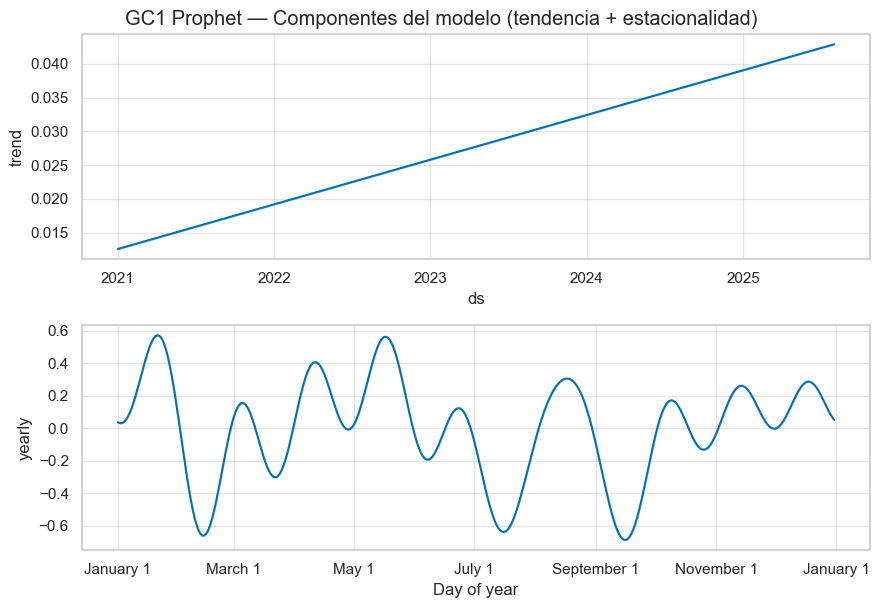

Gráfico de componentes guardado → gc1_prophet_componentes.png


In [11]:
# Prophet genera su propio gráfico de componentes sobre los datos de train
future_full = model.make_future_dataframe(periods=n_test, freq='MS')
forecast_full = model.predict(future_full)

fig_comp = model.plot_components(forecast_full)
fig_comp.suptitle('GC1 Prophet — Componentes del modelo (tendencia + estacionalidad)', y=1.01)
fig_comp.savefig(RESULTADOS_DIR / 'gc1_prophet_componentes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico de componentes guardado → gc1_prophet_componentes.png")

## 10. Gráfico: Predicción vs Real

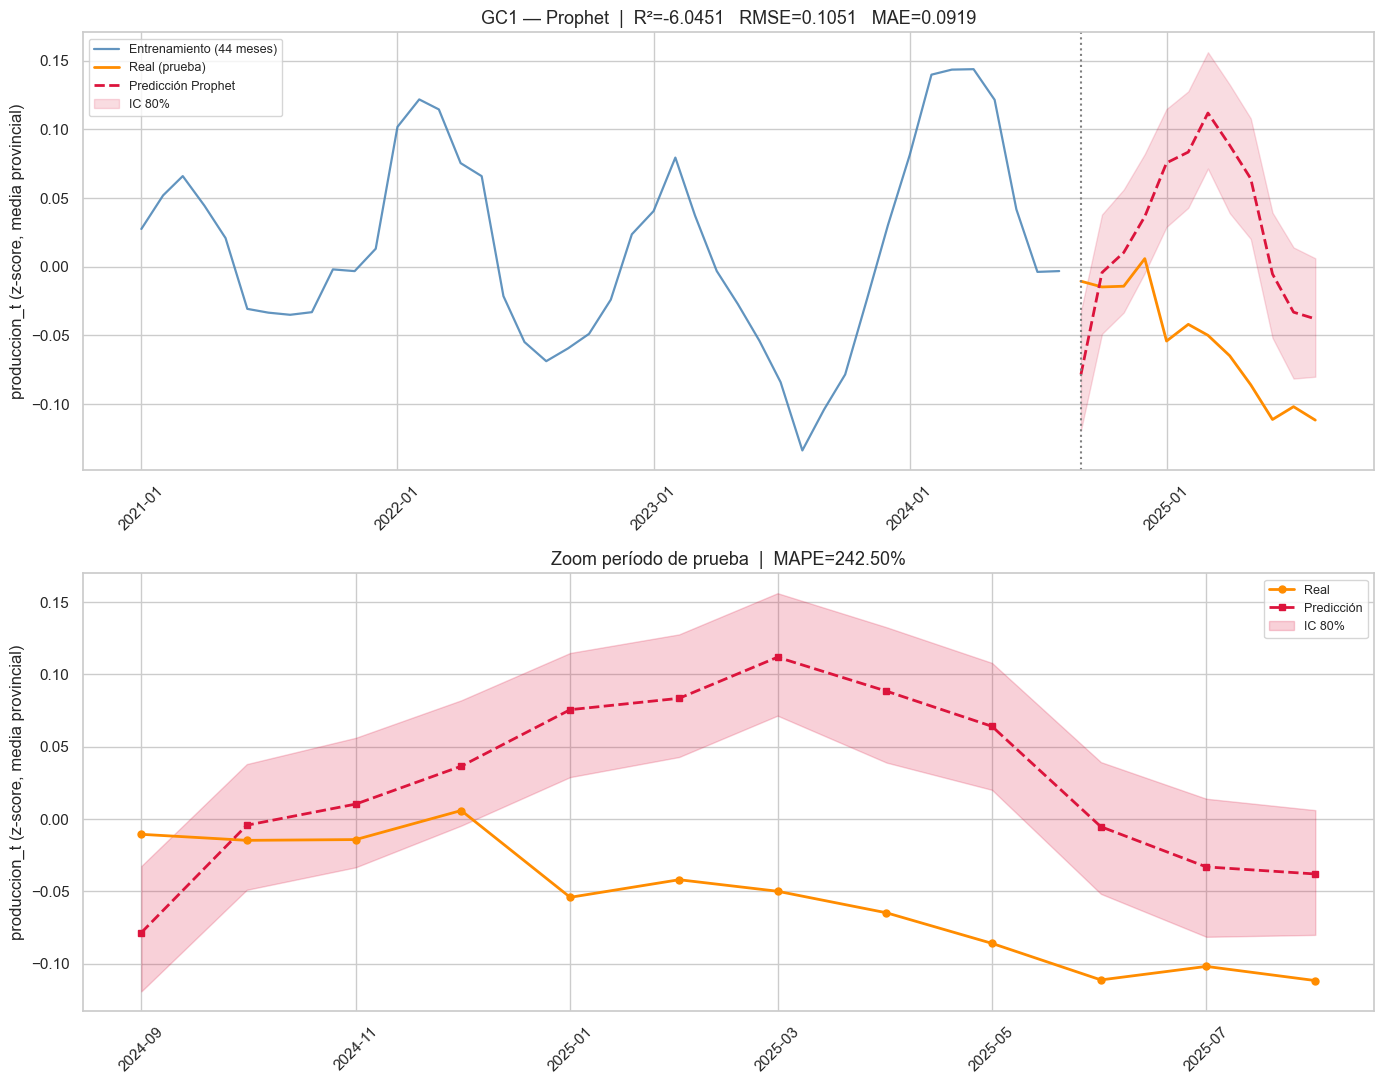

Gráfico guardado → gc1_prophet_prediccion_vs_real.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# --- Panel superior: serie completa ---
axes[0].plot(y_train_raw.index, y_train_raw.values,
             label=f'Entrenamiento ({n_train} meses)',
             color='steelblue', linewidth=1.6, alpha=0.85)
axes[0].plot(y_test_raw.index, y_test_raw.values,
             label='Real (prueba)', color='darkorange', linewidth=2)
axes[0].plot(y_test_raw.index, y_pred,
             label='Predicción Prophet', color='crimson', linewidth=2, linestyle='--')
axes[0].fill_between(y_test_raw.index, ci_lower, ci_upper,
                      alpha=0.15, color='crimson', label='IC 80%')
axes[0].axvline(split_date, color='gray', linestyle=':', linewidth=1.5)
axes[0].set_title(
    f'GC1 — Prophet  |  R²={r2:.4f}   RMSE={rmse:.4f}   MAE={mae:.4f}',
    fontsize=13
)
axes[0].set_ylabel('produccion_t (z-score, media provincial)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

# --- Panel inferior: zoom período de prueba ---
axes[1].plot(y_test_raw.index, y_test_raw.values,
             label='Real', color='darkorange', linewidth=2, marker='o', markersize=5)
axes[1].plot(y_test_raw.index, y_pred,
             label='Predicción', color='crimson', linewidth=2, linestyle='--', marker='s', markersize=5)
axes[1].fill_between(y_test_raw.index, ci_lower, ci_upper,
                      alpha=0.2, color='crimson', label='IC 80%')
if not np.isnan(mape):
    titulo_zoom = f'Zoom período de prueba  |  MAPE={mape:.2f}%'
else:
    titulo_zoom = 'Zoom período de prueba'
axes[1].set_title(titulo_zoom, fontsize=13)
axes[1].set_ylabel('produccion_t (z-score, media provincial)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plot_path = RESULTADOS_DIR / 'gc1_prophet_prediccion_vs_real.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado → {plot_path.name}")

## 11. Resumen final y comparativa GC1

In [13]:
print("\n" + "=" * 52)
print("  RESUMEN GC1 — Prophet")
print("=" * 52)
for k, v in metricas.items():
    print(f"  {k:<32}: {v}")
print("=" * 52)

# Comparativa con SARIMA si existe
sarima_path = RESULTADOS_DIR / 'gc1_sarima_metricas.json'
if sarima_path.exists():
    with open(sarima_path) as f:
        sarima_m = json.load(f)
    print("\n" + "=" * 60)
    print("  COMPARATIVA GC1: SARIMA vs Prophet (conjunto de prueba)")
    print("=" * 60)
    print(f"  {'Métrica':<12} {'SARIMA':>14} {'Prophet':>14}")
    print(f"  {'-'*40}")
    for m in ['MAE', 'RMSE', 'MAPE_pct', 'R2']:
        v_sarima  = sarima_m.get(m)
        v_prophet = metricas.get(m)
        label_s = f"{v_sarima:.4f}"  if v_sarima  is not None else 'N/A'
        label_p = f"{v_prophet:.4f}" if v_prophet is not None else 'N/A'
        mejor = '<<' if (v_prophet is not None and v_sarima is not None
                         and m != 'R2' and v_prophet < v_sarima) else ''
        if m == 'R2':
            mejor = '<<' if (v_prophet is not None and v_sarima is not None
                             and v_prophet > v_sarima) else ''
        print(f"  {m:<12} {label_s:>14} {label_p:>14}  {mejor}")
    print("=" * 60)

print("\nArchivos generados en resultados/gc1/:")
for f in sorted(RESULTADOS_DIR.iterdir()):
    print(f"  {f.name:<48} {f.stat().st_size/1024:>7.1f} KB")


  RESUMEN GC1 — Prophet
  modelo                          : GC1_Prophet
  changepoint_prior_scale         : 0.05
  seasonality_mode                : additive
  n_train                         : 44
  n_test                          : 12
  split_date                      : 2024-09-01
  MAE                             : 0.091884
  RMSE                            : 0.105071
  MAPE_pct                        : 242.5042
  R2                              : -6.0451
  nota                            : metricas en escala z-score — media provincial (Fase 2)

  COMPARATIVA GC1: SARIMA vs Prophet (conjunto de prueba)
  Métrica              SARIMA        Prophet
  ----------------------------------------
  MAE                  0.1006         0.0919  <<
  RMSE                 0.1179         0.1051  <<
  MAPE_pct           270.5880       242.5042  <<
  R2                  -7.8644        -6.0451  <<

Archivos generados en resultados/gc1/:
  gc1_prophet_componentes.png                         98.0 KB
 